In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("="*60)
print("FLIGHT DELAY PREDICTION BASED ON WEATHER")
print("="*60)
print("[1/6] Veri yükleniyor...")
data = pd.read_csv('/content/sample_data/flights_with_weather_2022.csv')
print(f"{len(data)} satır, {len(data.columns)} sütun yüklendi")

FLIGHT DELAY PREDICTION BASED ON WEATHER
[1/6] Veri yükleniyor...
194917 satır, 66 sütun yüklendi


In [ ]:
# Check available columns
print("Available columns:")
print(data.columns.tolist())
print("\n" + "="*60)

Available columns:
['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrDelay', 'ArrDel15', '

In [ ]:
#veri temizleme
data = data[(data['Cancelled'] == False) & (data['Diverted'] == False)]
print(f"✓ İptal/Yönlendirme filtrelendi: {len(data)} satır kaldı")

data = data.dropna(subset=['DepDelayMinutes', 'temp_max', 'temp_min',
                            'precipitation', 'windspeed_max', 'weather_code'])
print(f"✓ Eksik değerler temizlendi: {len(data)} satır kaldı")

✓ İptal/Yönlendirme filtrelendi: 190982 satır kaldı
✓ Eksik değerler temizlendi: 190981 satır kaldı


In [ ]:
data['Target'] = data['DepDel15'].fillna(0).astype(int)
print(f"Gecikme dağılımı:")
print(f" - Zamanında: {(data['Target'] == 0).sum()} (%{(data['Target'] == 0).sum() / len(data) * 100:.1f})")
print(f" - Gecikmeli (15+ dk): {(data['Target'] == 1).sum()} (%{(data['Target'] == 1).sum() / len(data) * 100:.1f})")

Gecikme dağılımı:
 - Zamanında: 143532 (%75.2)
 - Gecikmeli (15+ dk): 47449 (%24.8)


In [ ]:
features_to_use = [
    'Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'Origin', 'Dest',
    'Distance', 'Airline', 'temp_max', 'temp_min', 'precipitation',
    'windspeed_max', 'weather_code'
]

print("\n Kategorik değişkenler encode ediliyor...")
le_dict = {}
for col in ['Origin', 'Dest', 'Airline']:
    le = LabelEncoder()
    data[col + '_encoded'] = le.fit_transform(data[col])
    le_dict[col] = le
    # Remove original column from features_to_use and add encoded version
    features_to_use.remove(col)
    features_to_use.append(col + '_encoded')

print(f"Final features: {features_to_use}")

# Train/Test verisini bölme
print("\n[3/6] Veri train/test olarak bölünüyor...")
X = data[features_to_use]  # Fixed: capital X (convention)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {len(X_train)} satır")
print(f"Test set: {len(X_test)} satır")


 Kategorik değişkenler encode ediliyor...
Final features: ['Month', 'DayofMonth', 'DayOfWeek', 'CRSDepTime', 'Distance', 'temp_max', 'temp_min', 'precipitation', 'windspeed_max', 'weather_code', 'Origin_encoded', 'Dest_encoded', 'Airline_encoded']

[3/6] Veri train/test olarak bölünüyor...
Train set: 152784 satır
Test set: 38197 satır


In [ ]:
print("\n Özellikler ölçeklendiriliyor...")
scaler = StandardScaler()
numeric_cols=['CRSDepTime', 'Distance', 'temp_max','temp_min','precipitation','windspeed_max']
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.fit_transform(X_test[numeric_cols])

#Model eğitimi
print("\n[4/6] Modeller eğitiliyor...")
print("Bu işlem birkaç dakika sürebilir...\n")


 Özellikler ölçeklendiriliyor...

[4/6] Modeller eğitiliyor...
Bu işlem birkaç dakika sürebilir...



In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random-Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
}

results = {}

In [ ]:
for name, model in models.items():  # Fixed: items() not item()
    print(f"{name} eğitiliyor...")
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)  # Fixed: y_pred_train not y_red_train
    y_pred_test = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    results[name] = {
        'model': model,
        'train_acc': train_acc,
        'test_acc': test_acc,  # Fixed: test_acc not test_Acc
        'y_pred': y_pred_test
    }

    print(f"Train Accuracy: {train_acc:.4f}")  # Fixed: :.4f not :4f
    print(f"Test Accuracy: {test_acc:.4f}\n")

print("\n[5/6] En iyi model değerlendiriliyor...")

best_model_name = max(results, key=lambda x: results[x]['test_acc'])
best_model = results[best_model_name]['model']  # Fixed: indexing syntax
best_pred = results[best_model_name]['y_pred']  # Fixed: indexing syntax

print(f"\nEN İyi Model: {best_model_name}")
print(f"   Test Accuracy: {results[best_model_name]['test_acc']:.4f}")

print("\nDetaylı Performans Raporu:")
print(classification_report(y_test, best_pred,
                          target_names=['Zamanında', 'Gecikmeli']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
print("\nConfusion Matrix:")  # Fixed: removed extra space
print(f"   Doğru Zamanında: {cm[0,0]}")
print(f"   Yanlış Gecikmeli: {cm[0,1]}")
print(f"   Yanlış Zamanında: {cm[1,0]}")
print(f"   Doğru Gecikmeli: {cm[1,1]}")

Logistic Regression eğitiliyor...
Train Accuracy: 0.7671
Test Accuracy: 0.7676

Random-Forest eğitiliyor...
Train Accuracy: 0.7976
Test Accuracy: 0.7918

Gradient Boosting eğitiliyor...
Train Accuracy: 0.7976
Test Accuracy: 0.7957

XGBoost eğitiliyor...
Train Accuracy: 0.7969
Test Accuracy: 0.7958


[5/6] En iyi model değerlendiriliyor...

EN İyi Model: XGBoost
   Test Accuracy: 0.7958

Detaylı Performans Raporu:
              precision    recall  f1-score   support

   Zamanında       0.81      0.95      0.88     28707
   Gecikmeli       0.69      0.33      0.44      9490

    accuracy                           0.80     38197
   macro avg       0.75      0.64      0.66     38197
weighted avg       0.78      0.80      0.77     38197


Confusion Matrix:
   Doğru Zamanında: 27308
   Yanlış Gecikmeli: 1399
   Yanlış Zamanında: 6400
   Doğru Gecikmeli: 3090


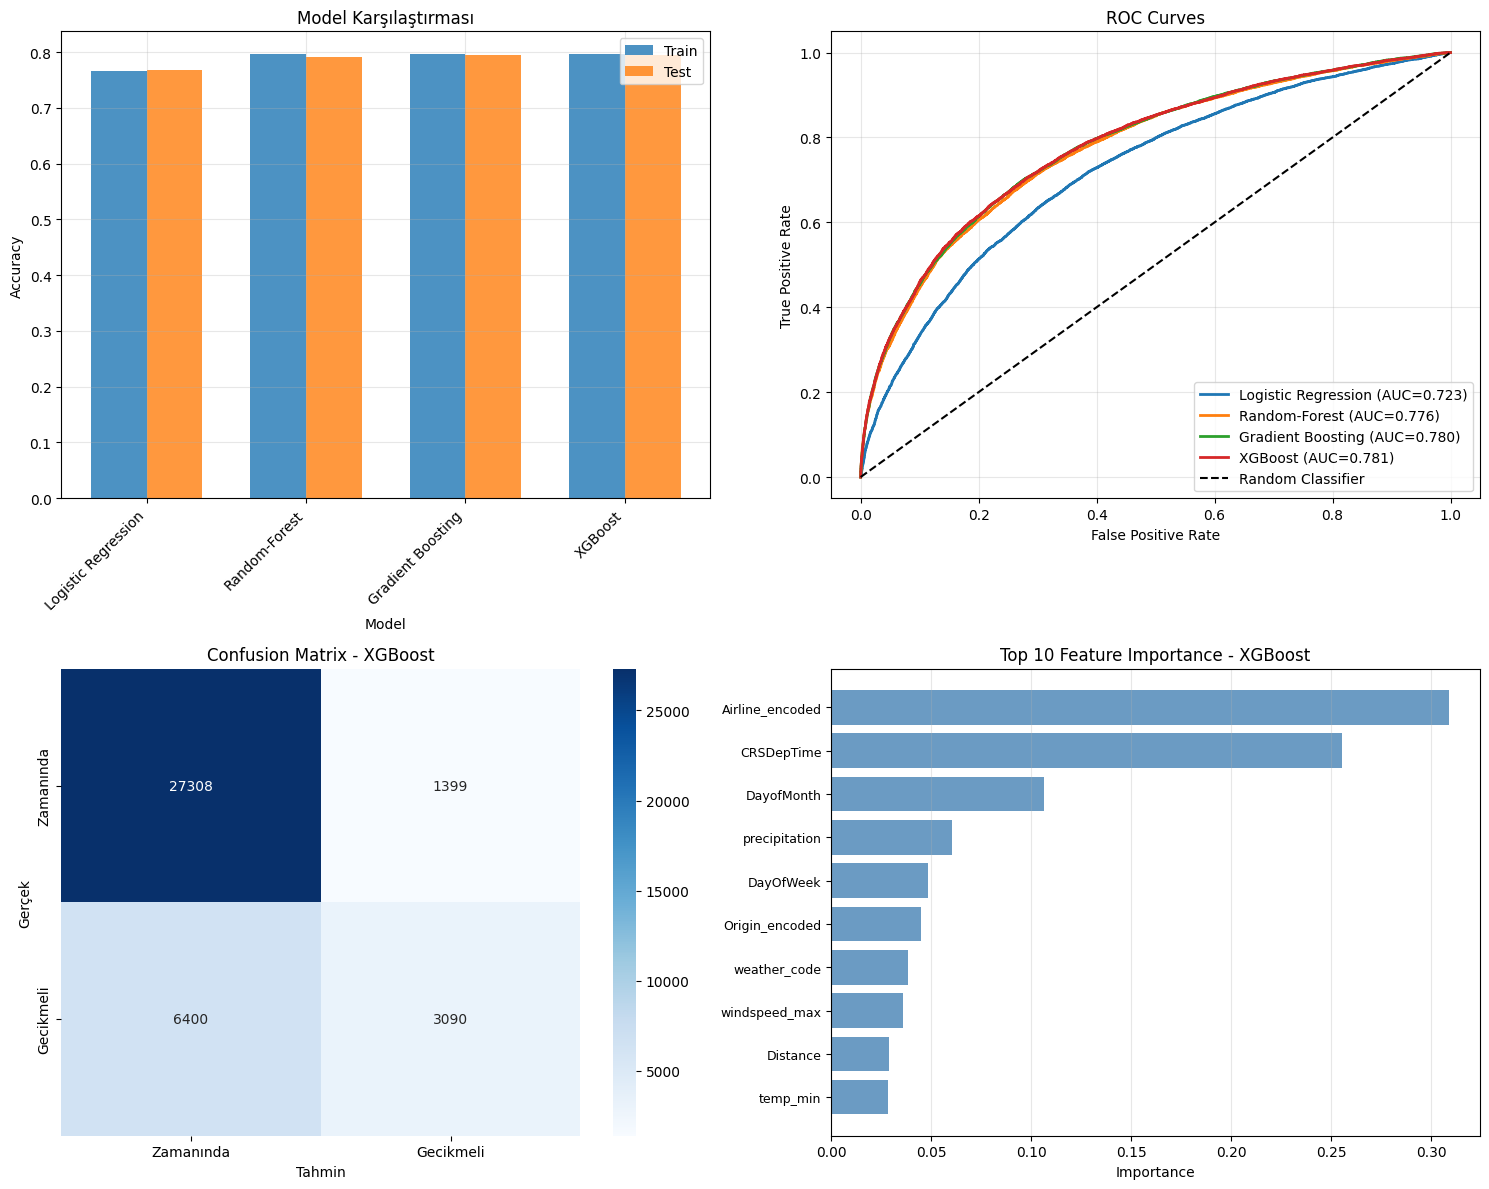

In [ ]:
# Grafikler
from sklearn.metrics import roc_curve, roc_auc_score
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Karşılaştırması (sol üst)
ax1 = axes[0, 0]
model_names = list(results.keys())
train_accs = [results[m]['train_acc'] for m in model_names]
test_accs = [results[m]['test_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, train_accs, width, label='Train', alpha=0.8)
ax1.bar(x + width/2, test_accs, width, label='Test', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Karşılaştırması')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. ROC Curve (sağ üst)
ax2 = axes[0, 1]
for name in model_names:
    model = results[name]['model']
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        ax2.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.3f})', linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Confusion Matrix (sol alt)
ax3 = axes[1, 0]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Zamanında', 'Gecikmeli'],
            yticklabels=['Zamanında', 'Gecikmeli'])
ax3.set_title(f'Confusion Matrix - {best_model_name}')
ax3.set_ylabel('Gerçek')
ax3.set_xlabel('Tahmin')

# 4. Feature Importance (sağ alt) - sadece Random Forest ve Gradient Boosting için
# Feature Importance grafiği için düzeltme
ax4 = axes[1, 1]
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-10:]  # En önemli 10 özellik

    ax4.barh(range(len(indices)), importances[indices], alpha=0.8, color='steelblue')
    ax4.set_yticks(range(len(indices)))
    ax4.set_yticklabels([features_to_use[i] for i in indices], fontsize=9)
    ax4.set_xlabel('Importance')
    ax4.set_title(f'Top 10 Feature Importance - {best_model_name}')
    ax4.grid(True, alpha=0.3, axis='x')
else:
    ax4.text(0.5, 0.5, f'{best_model_name}\nFeature importance\nmevcut değil',
             ha='center', va='center', fontsize=12)
    ax4.set_title('Feature Importance')
    ax4.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#confusion matrix
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title(f'Confusion Matrix - {best_model_name}')
ax2.set_ylabel('Gerçek')
ax2.set_xlabel('Tahmin')
ax2.set_xticklabels(['Zamanında', 'Gecikmeli'])
ax2.set_yticklabels(['Zamanında', 'Gecikmeli'])

[Text(0, 0.5, 'Zamanında'), Text(0, 1.5, 'Gecikmeli')]

In [ ]:
#feature importance
if best_model_name == 'XGBoost' or best_model_name == 'Random Forest':
    ax3 = axes[1, 0]
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[-10:]  # Top 10

        ax3.barh(range(len(indices)), importances[indices])
        ax3.set_yticks(range(len(indices)))
        ax3.set_yticklabels([features_to_use[i] for i in indices])
        ax3.set_xlabel('Önem Skoru')
        ax3.set_title('Top 10 Önemli Özellikler')
        ax3.grid(True, alpha=0.3)
else:
    ax3 = axes[1, 0]
    ax3.text(0.5, 0.5, 'Feature importance\nsadece tree-based\nmodeller için',
             ha='center', va='center', fontsize=12)
    ax3.axis('off')

In [ ]:
#gecikme oranı - hava durumu kodu
ax4 = axes[1, 1]
weather_delay = data.groupby('weather_code')['Target'].mean().sort_values(ascending=False).head(10)
ax4.bar(range(len(weather_delay)), weather_delay.values)
ax4.set_xlabel('Hava Durumu Kodu')
ax4.set_ylabel('Gecikme Oranı')
ax4.set_title('Hava Durumuna Göre Gecikme Oranı (Top 10)')
ax4.set_xticks(range(len(weather_delay)))
ax4.set_xticklabels(weather_delay.index, rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [ ]:
print("\n" + "=" * 60)
print("TÜM İŞLEMLER TAMAMLANDI!")
print("=" * 60)
print(f"\n En iyi model: {best_model_name}")
print(f"Test accuracy: {results[best_model_name]['test_acc']:.4f}")


TÜM İŞLEMLER TAMAMLANDI!

 En iyi model: XGBoost
Test accuracy: 0.7958
